# EDA (Exploratory data Analysis):


1.load the datasets

2.cleaning the data(Finding the missing values,duplicates,types)

3.Treatment of outliers

4.Univariate & bivariate and Multivariate Analysis

5.Insights for each and every step


Outlier:a data point that is significantly different from other observations in a dataset.

## How outliers will come----?
1.Measurement Errors.

2.Data entry mistakes

## Why they are important---?
1.They can be errors

2.They  eggect the data analysis

## How to identify the outliers---?
1.Statistical Methods:

----> IQR(Interquartile Range)

---->Z-score

2.Visualization techniques

----> Box Plots

---->Scatter Plots

---->Histograms


#### Univariate analysis - a method that analysis a single variable to describe its characteristics and summarize data.
#### -> It involves only one variable
#### Bivariate analysis- it will give the relationship b.w 2 variables.It helps to find if there is an co relation,association or connection b.w the 2 variables.
#### -> It involves 2 variables(x & y)
#### Mutlivariate analysis- To understand how multiple factors interact and influence each other.
#### It involves more than 2

Eg:
How our age,income and education level whether influence the purchasing behaviour



# ETL

## EDA :< Dataset >

1.Load & Overview

2.cleaning the dataset(missing,duplicates,datatypes)

3.Uni,bi,multi analysis

4.Outlier - IQR

5.Insights

6.Key Insights

### Feature Engineering is the process of turning raw data into useful features. " that helps to improve the performance of machine learning models "

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Option 1: load CSV from file
# df = pd.read_csv("titanic.csv")

# Option 2: load Seaborn built-in Titanic dataset
df = sns.load_dataset("titanic")

# Display first 5 rows
print(df.head())

# Shape of dataset
print("\nShape of dataset:", df.shape)

# Info of dataset
print("\nInfo of dataset:")
df.info()

# Summary statistics
print("\nSummary statistics:")
print(df.describe(include='all'))


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Shape of dataset: (891, 15)

Info of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       ------

In [4]:
# Missing values analysis

missing=pd.DataFrame({
'missing_count ':df.isnull().sum(),
'missing_percent':(df.isnull().sum()/len(df))*100

})
missing.sort_values(by='missing_percent',ascending=False)


,missing_count,missing_percent
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000


In [11]:
# 4. Handling missing values

# Fill numeric missing values with mean
df['age'] = df['age'].fillna(df['age'].mean())

# Fill categorical missing values with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop 'deck' column if it exists
df.drop(columns=['deck'], inplace=True, errors='ignore')

# Check missing values after cleaning
print("Missing values after cleaning:\n", df.isnull().sum())


Missing values after cleaning:
 survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


Insight: wefilled important coloumns and removes highly missing ones.

This keeps maximum information while maing the dataset clean.

In [14]:
# Duplictes & Data type check

print("Duplicate rows: ",df.duplicated().sum())

# Convert some columns to categorical type
df['class'] = df['class'].astype('category')
df['sex'] =df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')

df.info()

Duplicate rows:  111
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    category
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    category
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(3), float64(2), int64(4), object(3)
memory usage: 67.5+ KB


Numerical Columns: Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')


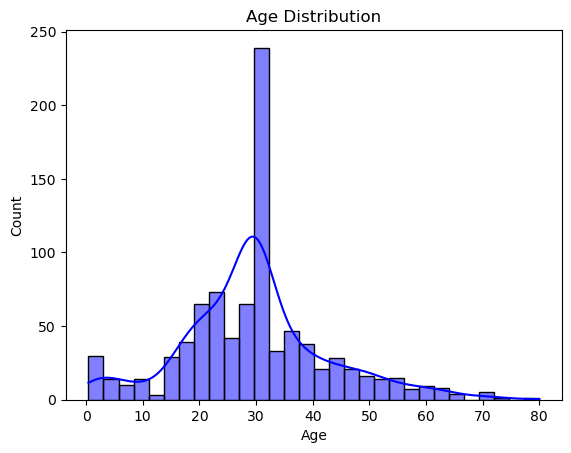

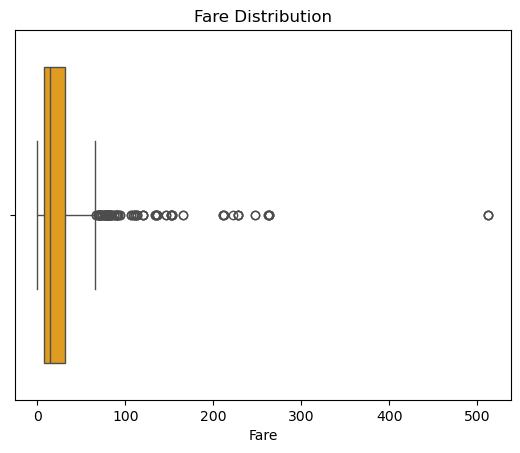

In [17]:
# Univariate analysis - Numerical Features
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Numerical Columns:", num_cols)

# Histogram: Age
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Box plot: Fare
sns.boxplot(x=df['fare'], color='orange')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.show()


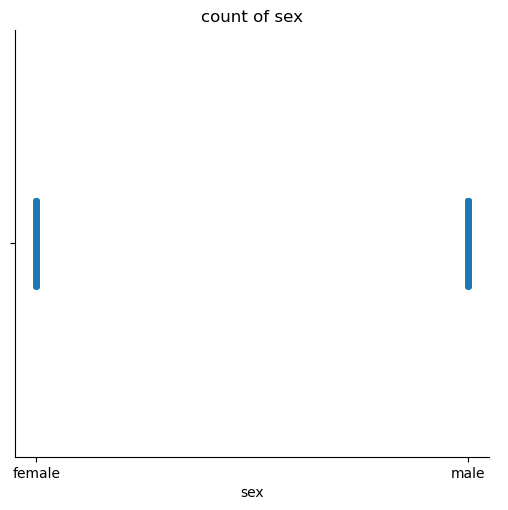

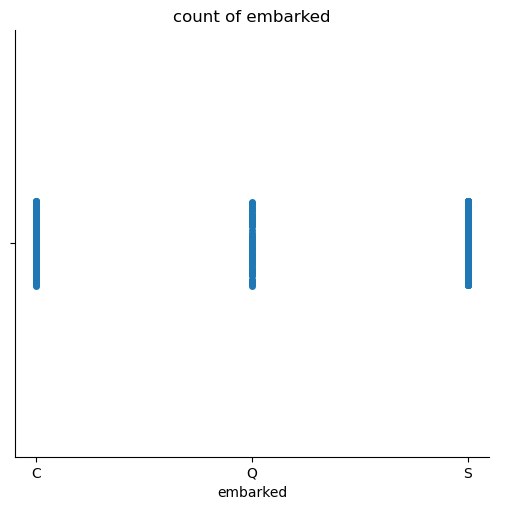

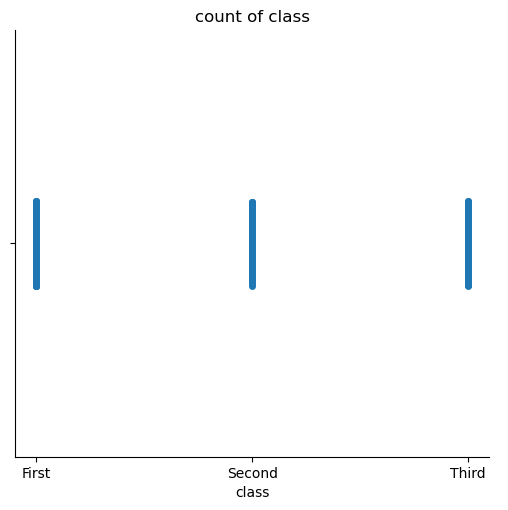

In [18]:
# Univariate Analysis - Categorical Features

cat_cols=df.select_dtypes('category').columns
for col in cat_cols:
    sns.catplot(x=col,data=df)
    plt.title(f"count of {col}")
    plt.show()

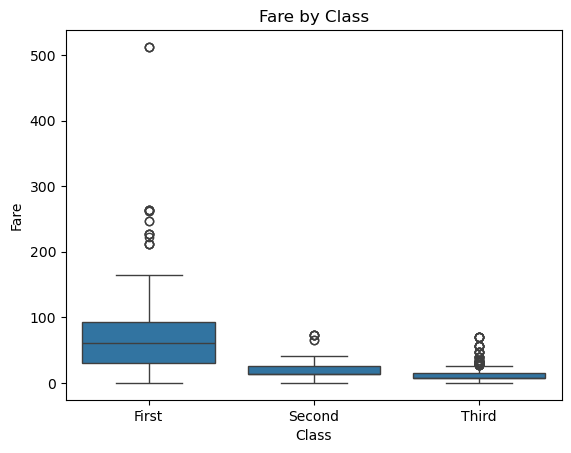

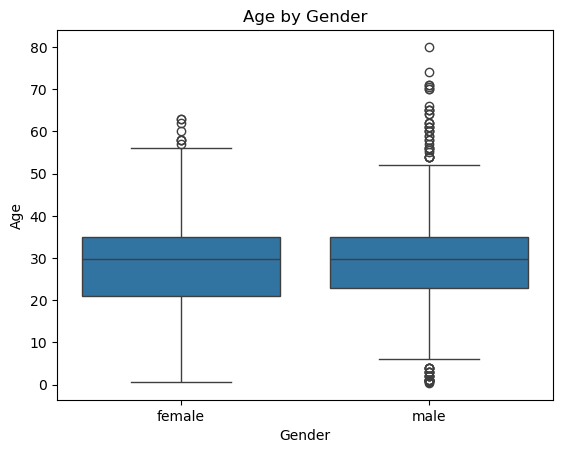

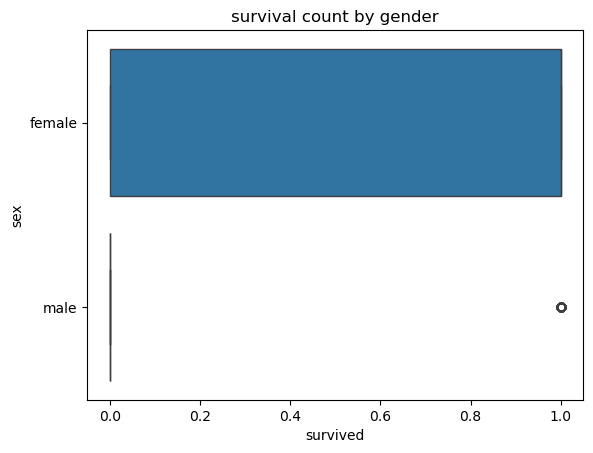

In [24]:
# Bivariate Analysis - Numerical vs Categorical

# Fare by class
sns.boxplot(x='class', y='fare', data=df)
plt.title("Fare by Class")
plt.xlabel("Class")
plt.ylabel("Fare")
plt.show()

# Age by gender
sns.boxplot(x='sex', y='age', data=df)
plt.title("Age by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()

sns.boxplot(x='survived', y='sex', data=df)
plt.title("survival count by gender")
plt.xlabel("survived")
plt.ylabel("sex")
plt.show()


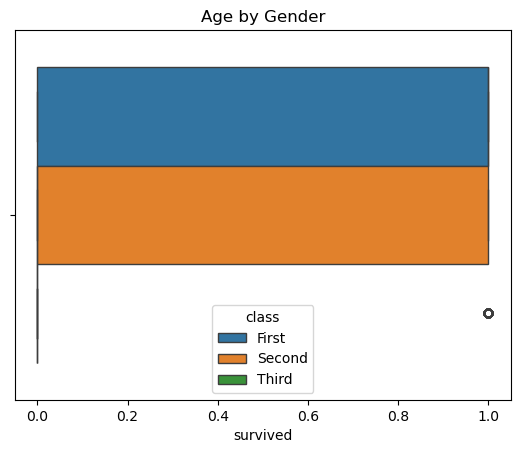

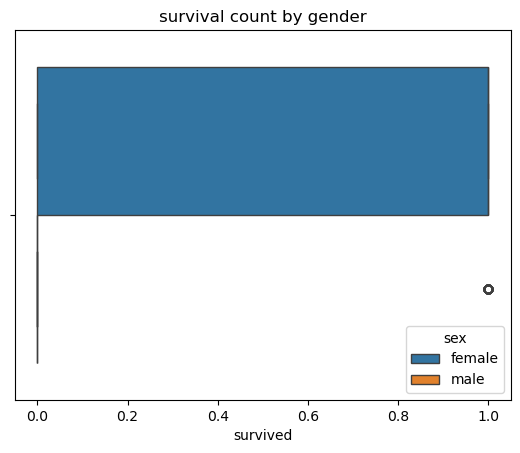

In [28]:
# Bivariate Analysis - Categorical vs Categorical



# Age by gender
sns.boxplot(x='survived', hue='class', data=df)
plt.title("Age by Gender")
plt.show()

sns.boxplot(x='survived', hue='sex', data=df)
plt.title("survival count by gender")
plt.show()


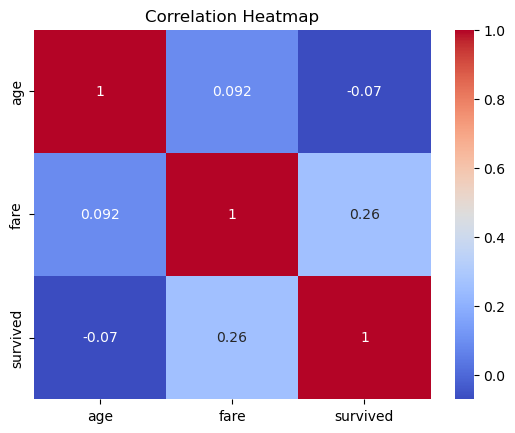

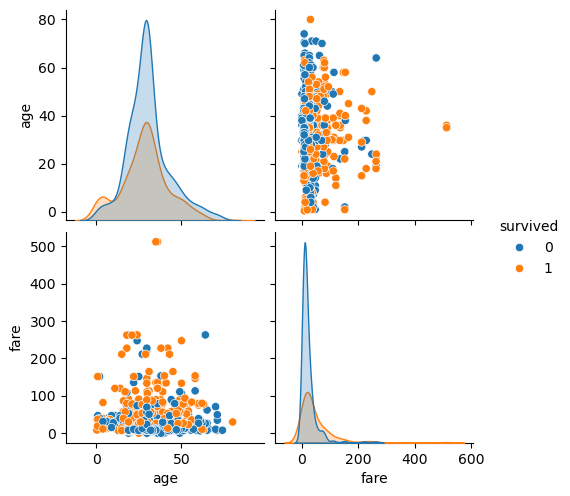

In [31]:
# Correlation and Multivariate Analysis

# Correlation Heatmap
corr = df[['age', 'fare', 'survived']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(df[['age', 'fare', 'survived']], hue='survived')
plt.show()


Insights:

1.Fare has a positive correlation with survival

2.Age shows a slight negative corelation with survival


116


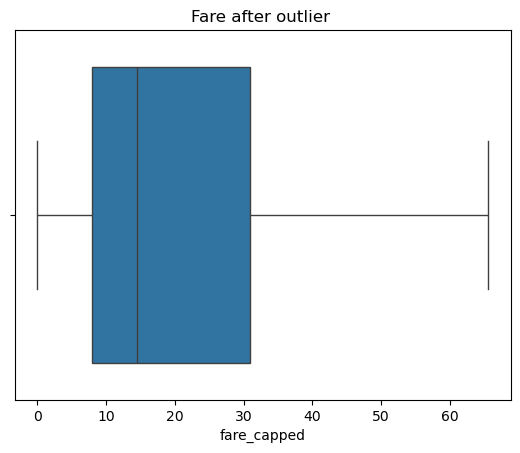

In [36]:
# Outlier Detection using IQR
Q1=df['fare'].quantile(0.25)
Q3=df['fare'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df[(df['fare']<lower)|(df['fare']>upper)]
print(len(outliers))

#Outliers

df['fare_capped']=df['fare'].clip(lower,upper)
sns.boxplot(x=df['fare_capped'])
plt.title('Fare after outlier ')
plt.show()

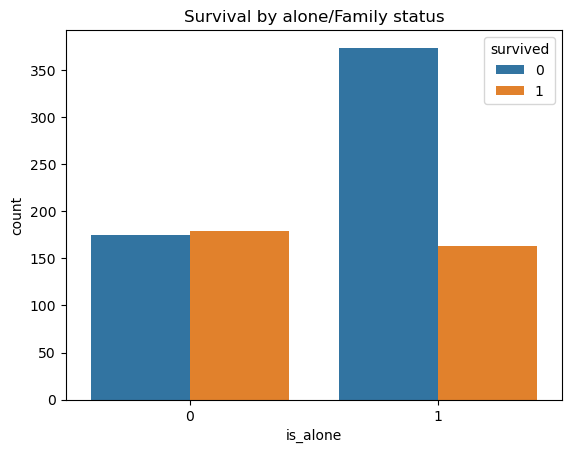

,family_size,is_alone,survived
0,2,0,0
1,2,0,1
2,1,1,1
3,2,0,1
4,1,1,0


In [40]:
# Feature Engineering

# Create new features

df['family_size']=df['sibsp']+df['parch']+1

df['is_alone']=(df['family_size']==1).astype(int)

sns.countplot(x='is_alone',hue='survived',data=df)

plt.title("Survival by alone/Family status")

plt.show()

df[['family_size','is_alone','survived']].head()

In [41]:
df.to_csv("Titanic cleaned.csv",index=False)
print("\n Cleaned Titanic data saved as titanic_cleaned.csv")



 Cleaned Titanic data saved as titanic_cleaned.csv
